In [1]:
from mmengine import Config
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import torch
import numpy as np
import torch.nn as nn
from tqdm import tqdm
import time

from AI4AO import PyramidWFS, PhaseDataset, FramePreprocess, DeformableMirror, imshow
from AI4AO.LossFunctions import LogResidualVarianceLoss

In [3]:
class PWFSNet(nn.Module):
    def __init__(self, DMParams):
        super().__init__()

        Nmodes = DMParams["Nmodes"]

        self.stem = nn.Sequential(
            # Process each pupil independently
            nn.Conv2d(4, 32, kernel_size=11, padding=5, groups=4),
            nn.GELU(),

            nn.Conv2d(32, 64, kernel_size=7, padding=3, groups=4),
            nn.GELU(),

            nn.MaxPool2d(2),      # 42 -> 21
        )

        self.encoder = nn.Sequential(
            nn.Conv2d(64, 64, 5, padding=2),
            nn.GELU(),

            nn.Conv2d(64, 64, 5, padding=2),
            nn.GELU(),

            nn.MaxPool2d(2),      # 21 -> 10

            nn.Conv2d(64, 128, 3, padding=1),
            nn.GELU(),

            nn.Conv2d(128, 128, 3, padding=1),
            nn.GELU(),

            nn.MaxPool2d(2),      # 10 -> 5

            nn.Conv2d(128, 256, 3, padding=1),
            nn.GELU(),

            nn.Conv2d(256, 256, 3, padding=1),
            nn.GELU(),

            nn.MaxPool2d(2),      # 10 -> 5

            nn.Conv2d(256, 512, 2, padding=1),
            nn.GELU(),

            nn.AdaptiveAvgPool2d(1)
        )

        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, Nmodes)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.encoder(x)
        return self.head(x)

In [ ]:
device = 'cuda' # set to "cpu" if Cuda is not available
    
paramfile = 'Rama_params.py'  # file of experimental parameters


# Config extraction
AtmosParams = Config.fromfile(paramfile)['AtmosParams']
WFSParams = Config.fromfile(paramfile)['WFSParams']
LoopParams = Config.fromfile(paramfile)['LoopParams']
TrainParams = Config.fromfile(paramfile)['TrainParams']
DMParams = Config.fromfile(paramfile)['DMParams']

Total trainable parameters: 2,070,672


C:\Users\franc\AppData\Local\Temp\ipykernel_29276\4101557790.py:44: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("../Data/Ekarus/EkarusCNN.pth")


In [ ]:


# Dataset creation
dataset = PhaseDataset(WFSParams, AtmosParams, LoopParams, DMParams, device)
dataset.generateClosedLoop = True


In [ ]:

# WFS creation
wfs = PyramidWFS(WFSParams, device)
PATH_WFS = "../Data/Rama/RamaWFS.pth"
wfs.LoadCalibration(PATH_WFS)
wfs.eval()
wfs.requires_grad_(False)

dm = DeformableMirror(WFSParams, DMParams, device)
PATH_DM = "../Data/Rama/RamaDM.pth"
dm.LoadCalibration(PATH_DM)
dm.eval()
dm.requires_grad_(False)
dm.IF *= dataset.pupil
dm.IF[:, dataset.pupil] -= dm.IF[:, dataset.pupil].mean(dim = (-1), keepdim = True)


In [ ]:
M2C = np.load("../Data/Rama/M2C.npy")
M2C = torch.from_numpy(M2C).to(device = device, dtype = torch.float32)
M2C = M2C[:, :DMParams["Nmodes"]]

z_inv = torch.linalg.pinv(dm(M2C.T).flatten(start_dim = -2))

In [ ]:

# frame processor creation
framePreprocessor = FramePreprocess(WFSParams, wfs, device)
framePreprocessor.ProcessReference(wfs.reference_intensity)


In [ ]:

# Phase reconstructor
phaseReconstructor = PWFSNet(DMParams).to(device = device)
try:
    checkpoint = torch.load("../Data/Ekarus/RamaCNN.pth")
    phaseReconstructor.load_state_dict(checkpoint)
except:
    print("Starting from scratch")


total_params = sum(p.numel() for p in phaseReconstructor.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params:,}")


In [ ]:


# Optimization parameters (learning rate lr and nb of runs)
lrn = TrainParams['lrn']
num_iterations = 1 # Closed loop iterations

# Number of training and testing run 
TrainRunNb = TrainParams['TrainRunNb']
optimizer_n = torch.optim.AdamW(phaseReconstructor.parameters(), lrn, fused = True)

# Setting the loss
loss_variance = LogResidualVarianceLoss(dataset.pupil)

# Track the loss
loss_tracker = torch.zeros(TrainRunNb // num_iterations, device=device)
loss_tracker_ideal = torch.zeros(TrainRunNb // num_iterations, device=device)


In [30]:
num_iterations = 1

In [12]:
phaseReconstructor.train()

progressBar = tqdm(range(TrainRunNb // num_iterations))

for u in progressBar:

    batch = dataset[0]
    phaseGT = batch["phase"]
    pupilGT = batch["pupil"]
    gain = batch["loop_gain"]
    leak = batch["loop_leak"]
    photons = batch["nphotons"]
    ron = batch["ron"]

    modes = torch.matmul(phaseGT.flatten(start_dim = -2), z_inv)

    wfs.SetPhotonsAndRON(photons, ron)

    # Closed-loop correction
    z_estimated = torch.zeros_like(modes)  # Start with zero correction 
    z_buffer = torch.zeros_like(modes)  
    z_output = torch.zeros_like(modes)    
    phase_reconstructed = torch.zeros_like(phaseGT)
    phase_reconstructed_iter = torch.zeros_like(phaseGT)
    phase_reconstructed_ideal = torch.zeros_like(phaseGT)
    phase_reconstructed_iter_ideal = torch.zeros_like(phaseGT)

    total_loss = 0
    ideal_loss = 0

    for i in range(num_iterations):
        # Get new WFS images after applying the correction
        if i > 0:
            batch = dataset[i]
            phaseGT = batch["phase"]
            pupilGT = batch["pupil"]
        residual_phase = phaseGT - phase_reconstructed

        modes = torch.matmul(phaseGT.flatten(start_dim = -2), z_inv)
        Ze = torch.matmul(residual_phase.flatten(start_dim = -2), z_inv)


        # Predict coefficients and update estimate
        z_estimated = z_estimated * leak + gain * z_buffer  # Apply correction with gain
        z_buffer = torch.clone(z_output)

        with torch.no_grad():
            wfs_frames = wfs(residual_phase, pupilGT)
            preprocessed_frames = framePreprocessor.ProcessFrame(wfs_frames)
        z_output = phaseReconstructor(preprocessed_frames)
        
        # Convert modes coefficients to full-resolution wavefront
        phase_reconstructed = dm(z_estimated @ M2C.T)
        phase_reconstructed_iter = dm(z_output @ M2C.T)
        
        # phase_reconstructed_ideal = dm(modes @ M2C.T)
        phase_reconstructed_iter_ideal = dm(Ze @ M2C.T)
        
        
        # Compute loss for this iteration
        total_loss += loss_variance((residual_phase - phase_reconstructed_iter)) / num_iterations

        # Compute ideal loss for comparison
        with torch.no_grad():
            ideal_loss += loss_variance((residual_phase - phase_reconstructed_iter_ideal)) / num_iterations

        
    # **Backpropagation**
    optimizer_n.zero_grad(set_to_none = True)
    
    total_loss.backward()
        
    optimizer_n.step()
    
    # **Track loss and parameters**
    
    loss_tracker[u] = total_loss.detach()
    loss_tracker_ideal[u] = ideal_loss.detach()
    
    if u % (300 // num_iterations) == 1:
        progressBar.set_postfix({'Loss': float(loss_tracker[u-100 // num_iterations:u].mean()), 'Loss_ideal': float(loss_tracker_ideal[u-100 // num_iterations:u].mean())})
        

100%|██████████| 5000/5000 [01:12<00:00, 68.62it/s, Loss=-0.989, Loss_ideal=-3.14]


<>:5: SyntaxWarning: invalid escape sequence '\p'
<>:5: SyntaxWarning: invalid escape sequence '\p'
C:\Users\franc\AppData\Local\Temp\ipykernel_29276\412108284.py:5: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel('Loss = $ln(var(\phi - \phi_{est}))$')


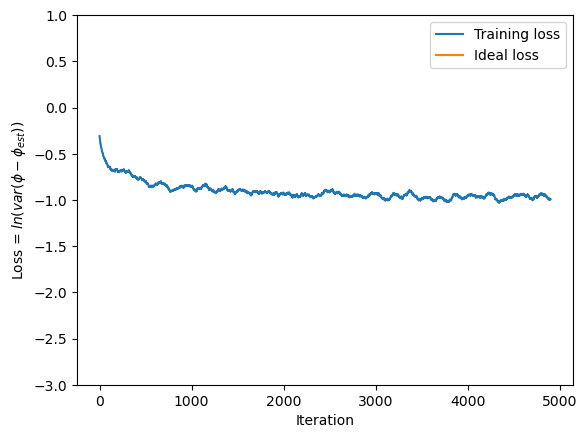

In [13]:
plt.plot(np.convolve(loss_tracker.cpu().detach().numpy(), np.ones(100) / 100, "valid"), label = 'Training loss')
plt.plot(np.convolve(loss_tracker_ideal.cpu().detach().numpy(), np.ones(100) / 100, "valid"), label = 'Ideal loss')
plt.legend()
plt.xlabel('Iteration')
plt.ylabel('Loss = $ln(var(\phi - \phi_{est}))$')
plt.ylim(-3,1)
plt.show()

In [ ]:
torch.save(phaseReconstructor.state_dict(), "../Data/Rama/RamaCNN.pth")

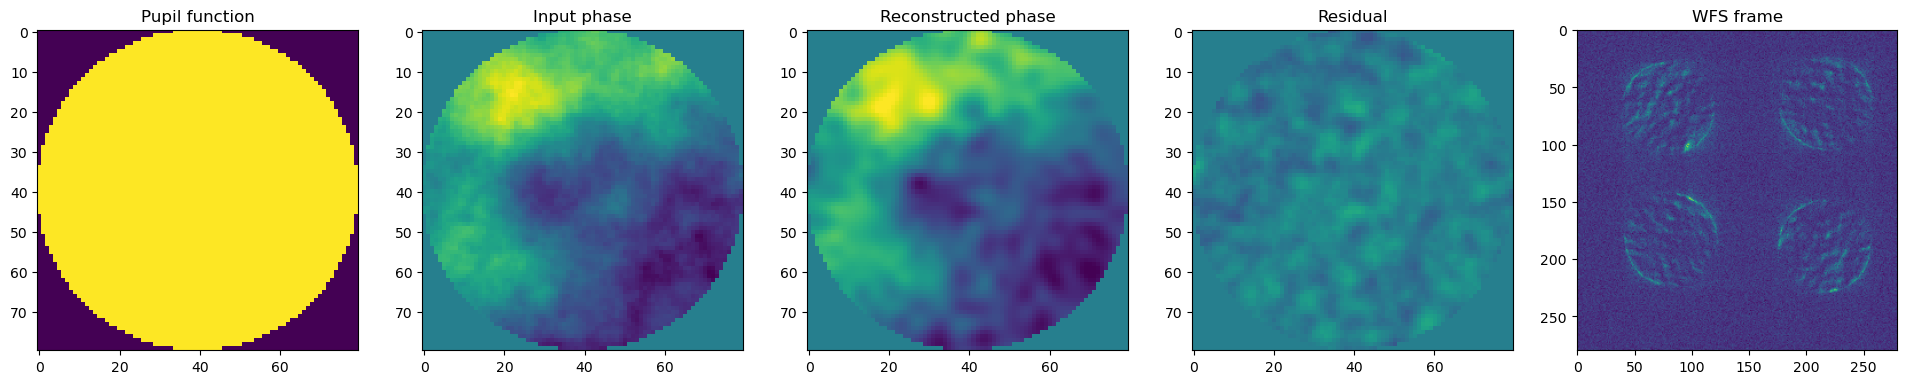

In [ ]:
with torch.no_grad():
    gain = 0.3
    dataset.Nphases = 1
    batch = dataset[0]
    phaseGT = batch["phase"]
    pupilGT = batch["pupil"]
    gain = batch["loop_gain"]
    leak = batch["loop_leak"]
    photons = batch["nphotons"]
    ron = batch["ron"]
    wfs.SetPhotonsAndRON(photons, ron)
    wfs_frames = wfs(phaseGT, pupilGT)
    preprocessed_frames = framePreprocessor.ProcessFrame(wfs_frames)
    z_output = phaseReconstructor(preprocessed_frames)

    phaseReconstructor.eval()

    fig, ax = plt.subplots(1,5, figsize=(24,18))
    handle = display(fig, display_id=True)
    img0 = ax[0].imshow(phaseGT[0].cpu().detach())
    img1 = ax[1].imshow(phaseGT[0].cpu().detach())
    img2 = ax[2].imshow(phaseGT[0].cpu().detach())
    img3 = ax[3].imshow(phaseGT[0].cpu().detach())
    img4 = ax[4].imshow(wfs_frames[0].cpu().detach())


    ax[0].set_title('Pupil function')
    ax[1].set_title('Input phase')
    ax[2].set_title('Reconstructed phase')
    ax[3].set_title('Residual')
    ax[4].set_title('WFS frame')

    a = time.perf_counter()
            
    # Closed-loop correction
    z_estimated = torch.zeros_like(z_output)  # Start with zero correction 
    phase_reconstructed = torch.zeros_like(phaseGT)    
    z_buffer = torch.zeros_like(z_output)  
    z_output = torch.zeros_like(z_output)      

    for i in range(100):
        a = time.perf_counter()
        # Get new WFS images after applying the correction
        if i > 0:
            batch = dataset[i]
            phaseGT = batch["phase"]
            pupilGT = batch["pupil"]
        # residual_phase = phaseGT - z_reconstructed
        residual_phase = phaseGT - phase_reconstructed 

        z_estimated = z_estimated * 0.999 + 0.3 * z_buffer  # Apply correction with gain
        z_buffer = torch.clone(z_output)

        wfs_frames = wfs(residual_phase, pupilGT)
        preprocessed_frames = framePreprocessor.ProcessFrame(wfs_frames, False)
        z_output = phaseReconstructor(preprocessed_frames)

    
        phase_reconstructed = dm(z_estimated @ M2C.T)  
        
        # clear_output(wait=True)
        img0.set_data((pupilGT[0] * dataset.pupil).cpu().detach().numpy())
        img0.set_clim(vmin=np.min(img0.get_array()), vmax=np.max(img0.get_array()))
        img1.set_data(phaseGT[0].cpu().detach().numpy())
        img1.set_clim(vmin=np.min(img1.get_array()), vmax=np.max(img1.get_array()))
        img2.set_data(phase_reconstructed[0].cpu().detach().numpy())
        img2.set_clim(vmin=np.min(img1.get_array()), vmax=np.max(img1.get_array()))
        img3.set_data(residual_phase[0].cpu().detach().numpy())
        img3.set_clim(vmin=np.min(img1.get_array()), vmax=np.max(img1.get_array()))
        img4.set_data(wfs_frames[0].cpu().detach().numpy())
        img4.set_clim(vmin=np.min(img4.get_array()), vmax=np.max(img4.get_array()))
        
    
        clear_output(wait = True)
        display(fig)
        # handle.update(fig)
        # display(fig)
        # fig.canvas.draw_idle()
        # fig.canvas.flush_events()
        
        
        #fig.canvas.draw()
        #fig.canvas.flush_events()
        plt.pause(0.001)
        
        b = time.perf_counter()
        
        print(f"Loop frequency = {1 / (b - a):.1f} Hz. ", end="\r", flush=True)


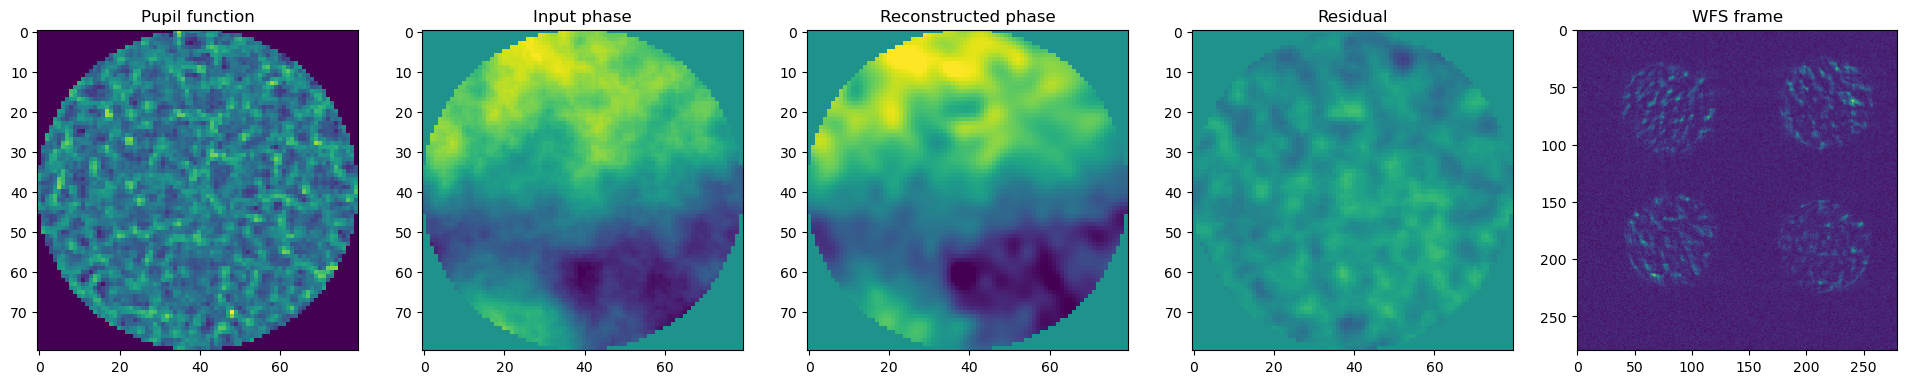

In [20]:
AtmosParams['Scintillation'] = True

# Dataset creation
dataset = PhaseDataset(WFSParams, AtmosParams, LoopParams, DMParams, device)

with torch.no_grad():
    gain = 0.3
    dataset.Nphases = 1
    batch = dataset[0]
    phaseGT = batch["phase"]
    pupilGT = batch["pupil"]
    gain = batch["loop_gain"]
    leak = batch["loop_leak"]
    photons = batch["nphotons"]
    ron = batch["ron"]
    wfs_frames = wfs(phaseGT, pupilGT)
    preprocessed_frames = framePreprocessor.ProcessFrame(wfs_frames)
    z_output = phaseReconstructor(preprocessed_frames)

    phaseReconstructor.eval()

    fig, ax = plt.subplots(1,5, figsize=(24,18))
    img0 = ax[0].imshow(phaseGT[0].cpu().detach())
    img1 = ax[1].imshow(phaseGT[0].cpu().detach())
    img2 = ax[2].imshow(phaseGT[0].cpu().detach())
    img3 = ax[3].imshow(phaseGT[0].cpu().detach())
    img4 = ax[4].imshow(wfs_frames[0].cpu().detach())


    ax[0].set_title('Pupil function')
    ax[1].set_title('Input phase')
    ax[2].set_title('Reconstructed phase')
    ax[3].set_title('Residual')
    ax[4].set_title('WFS frame')

    a = time.perf_counter()
            
    # Closed-loop correction
    z_estimated = torch.zeros_like(z_output)  # Start with zero correction 
    phase_reconstructed = torch.zeros_like(phaseGT)    
    z_buffer = torch.zeros_like(z_output)  
    z_output = torch.zeros_like(z_output)      

    for i in range(100):
        a = time.perf_counter()
        # Get new WFS images after applying the correction
        if i > 0:
            batch = dataset[i]
            phaseGT = batch["phase"]
            pupilGT = batch["pupil"]
        # residual_phase = phaseGT - z_reconstructed
        residual_phase = phaseGT - phase_reconstructed 
        

        z_estimated = z_estimated * 0.999 + gain * z_buffer  # Apply correction with gain
        z_buffer = torch.clone(z_output)

        wfs_frames = wfs(residual_phase, pupilGT)
        preprocessed_frames = framePreprocessor.ProcessFrame(wfs_frames)
        z_output = phaseReconstructor(preprocessed_frames)
    
        phase_reconstructed = dm(z_estimated @ M2C.T)  
        phase_reconstructed *= wfs.pupil
        phase_reconstructed -= wfs.pupil.unsqueeze(0) * phase_reconstructed[wfs.pupil.unsqueeze(0) != 0].mean()
        
        clear_output(wait=True)
        img0.set_data((pupilGT[0] * dataset.pupil).cpu().detach().numpy())
        img0.set_clim(vmin=np.min(img0.get_array()), vmax=np.max(img0.get_array()))
        img1.set_data(phaseGT[0].cpu().detach().numpy())
        img1.set_clim(vmin=np.min(img1.get_array()), vmax=np.max(img1.get_array()))
        img2.set_data(phase_reconstructed[0].cpu().detach().numpy())
        img2.set_clim(vmin=np.min(img1.get_array()), vmax=np.max(img1.get_array()))
        img3.set_data(residual_phase[0].cpu().detach().numpy())
        img3.set_clim(vmin=np.min(img1.get_array()), vmax=np.max(img1.get_array()))
        img4.set_data(wfs_frames[0].cpu().detach().numpy())
        img4.set_clim(vmin=np.min(img4.get_array()), vmax=np.max(img4.get_array()))
        display(fig, clear=True)
        
        
        #fig.canvas.draw()
        #fig.canvas.flush_events()
        plt.pause(0.001)
        
        b = time.perf_counter()
        
        # print(f"Loop frequency = {1 / (b - a):.1f} Hz. Residual variance = {Trained_End2EndWFS.GetPhaseVariance(residual_phase[0]).item():.2f} ", end="\r", flush=True)